# Training and evaluation results

This notebook scans the JSON summaries each time it runs,
so new models, checkpoints, variants, and runs appear
without manually copying numbers into the notebook.

Data conventions:

- Data source : JSON files under `results/`
- Best-checkpoint tables select the highest configured pass@k within each
  algorithm/variant across repeated runs. Hint-trained generator settings remain
  separate even though schema-v2 records those setting names in the `run` field.
- Older AIME summaries do not contain `arm` or `eval_config`;
  their identities are recovered from the directory layout and are marked as schema 0.
- Scores are shown on a 0–1 scale in tables and as percentages in plots.


In [9]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    """Work when launched from the repo root, eval/viz, or a parent directory."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results").is_dir() and (candidate / "train").is_dir():
            return candidate
    raise FileNotFoundError("Could not find a repository root containing results/ and train/")


ROOT = find_repo_root()
RESULTS = ROOT / "results"
print(f"Repository: {ROOT}")
print(f"Results:    {RESULTS}")

Repository: /home/ujan/self-distill
Results:    /home/ujan/self-distill/results


In [10]:
#
# For the initial overview, checkpoint curves are more informative than a single bar
# per method: they show training dynamics and make clear
# which checkpoint is being compared. Each panel uses the exact base-model
# evaluation as a horizontal reference. Variants and repeated runs remain separate series.
#

In [14]:
AIME_YEAR = 24  # Select 24, 25, 26, ...
AIME_DATASET = f"aime{AIME_YEAR}"
AIME_LABEL = AIME_DATASET.upper()
AIME_DIR = RESULTS / AIME_DATASET
AVAILABLE_AIME_DATASETS = sorted(
    path.name for path in RESULTS.glob("aime*") if path.is_dir()
)
if not AIME_DIR.is_dir():
    raise FileNotFoundError(
        f"No results directory for {AIME_LABEL}: {AIME_DIR}. "
        f"Available AIME datasets: {AVAILABLE_AIME_DATASETS}"
    )

def read_json(path: Path) -> dict:
    with path.open() as handle:
        return json.load(handle)


def checkpoint_number(step: str | None) -> int | None:
    if not step:
        return None
    match = re.fullmatch(r"checkpoint-(\d+)", step)
    return int(match.group(1)) if match else None


def fallback_aime_arm(path: Path) -> dict:
    """Recover arm identity from the path used by schema-0 summaries."""
    parts = path.relative_to(AIME_DIR).parts[:-1]  # drop summary.json
    if len(parts) == 2 and parts[0] == "base":
        return {
            "algo": "base",
            "model": parts[1],
            "train_dataset": None,
            "variant": None,
            "run": None,
            "step": "base",
        }

    if len(parts) < 4:
        raise ValueError(f"Unrecognized {AIME_LABEL} result path: {path}")

    train_dataset, model, algo = parts[:3]
    step = parts[-1]
    extras = list(parts[3:-1])
    if algo == "sdft" and len(extras) >= 2 and extras[0] == "hint_trained":
        return {
            "algo": algo,
            "model": model,
            "train_dataset": train_dataset,
            "variant": "hint_trained",
            "run": "/".join(extras[1:]),
            "step": step,
        }
    run_parts = [part for part in extras if re.fullmatch(r"run-\d+", part)]
    variant_parts = [part for part in extras if part not in run_parts]
    return {
        "algo": algo,
        "model": model,
        "train_dataset": train_dataset,
        "variant": "/".join(variant_parts) or None,
        "run": run_parts[0] if run_parts else None,
        "step": step,
    }


def load_aime() -> pd.DataFrame:
    rows = []
    for path in sorted(AIME_DIR.rglob("summary.json")):
        summary = read_json(path)
        fallback = fallback_aime_arm(path)
        arm = {**fallback, **(summary.get("arm") or {})}
        eval_config = summary.get("eval_config") or {}
        recorded_eval_dataset = eval_config.get("eval_dataset")
        if recorded_eval_dataset not in (None, AIME_DATASET):
            raise ValueError(
                f"{path} records eval dataset {recorded_eval_dataset!r}, "
                f"expected {AIME_DATASET!r}"
            )
        sampling = eval_config.get("sampling") or {}
        row = {
            **arm,
            "checkpoint": checkpoint_number(arm.get("step")),
            "is_base": arm.get("algo") == "base",
            "schema_version": summary.get("schema_version", 0),
            "dataset_size": summary.get("dataset_size"),
            "n_samples": summary.get("n_samples"),
            "max_tokens": summary.get("max_tokens"),
            "temperature": sampling.get("temperature"),
            "top_p": sampling.get("top_p"),
            "top_k": sampling.get("top_k"),
            "generation_seed": sampling.get("seed"),
            "extraction_failures": summary.get("extraction_failures"),
            "total_samples": summary.get("total_samples"),
            "elapsed_s": summary.get("elapsed_s"),
            "source": str(path.relative_to(ROOT)),
        }
        row.update(summary.get("pass_at_k") or {})
        rows.append(row)

    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    for column in ("variant", "run", "train_dataset"):
        frame[column] = frame[column].where(frame[column].notna(), None)
    return frame.sort_values(
        ["model", "is_base", "algo", "variant", "run", "checkpoint"],
        na_position="first",
    ).reset_index(drop=True)


aime = load_aime()
print(f"Loaded {len(aime)} {AIME_LABEL} summaries across {aime.model.nunique()} models.")
display(
    aime.groupby(
        ["schema_version", "dataset_size", "n_samples", "max_tokens"],
        dropna=False,
    ).size().rename("summary_files").reset_index()
)

Loaded 498 AIME24 summaries across 8 models.


,schema_version,dataset_size,n_samples,max_tokens,summary_files
0,0,30,16,32000,92
1,2,30,16,32000,254
2,3,30,16,32000,152


In [15]:
AIME_BEST_K = 1  # Choose 1, 8, or 16.
AIME_BEST_METRIC = f"pass@{AIME_BEST_K}"
if AIME_BEST_K not in {1, 8, 16}:
    raise ValueError(f"AIME_BEST_K must be one of 1, 8, or 16; got {AIME_BEST_K}")


def method_label(row: pd.Series, include_run: bool = True) -> str:
    if row["algo"] == "base":
        return "Base"
    label = str(row["algo"]).upper()
    if row.get("variant"):
        label += " [" + str(row["variant"]) + "]"
    if include_run and row.get("run"):
        label += " · " + str(row["run"])
    return label


def best_aime_by_algo(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Select the best checkpoint per model, dataset, algorithm, and variant.

    Repeated runs compete, but each ``hint_trained`` run names a distinct hint-generator
    setting and therefore remains separate. If scores tie, prefer the earlier checkpoint,
    then the run name for a deterministic result. The base evaluation is treated as the
    ``base`` algorithm with no variant.
    """
    candidates = frame.dropna(subset=[metric]).copy()
    candidates["_checkpoint_sort"] = candidates["checkpoint"].fillna(-1)
    candidates["_dataset_key"] = candidates["train_dataset"].fillna("")
    candidates["_variant_key"] = candidates["variant"].fillna("")
    candidates["_setting_key"] = candidates["run"].where(
        candidates["variant"].eq("hint_trained"), ""
    ).fillna("")
    candidates["_run_sort"] = candidates["run"].fillna("")
    candidates = candidates.sort_values(
        [
            "model", "_dataset_key", "algo", "_variant_key", "_setting_key", metric,
            "_checkpoint_sort", "_run_sort",
        ],
        ascending=[True, True, True, True, True, False, True, True],
    )
    best = candidates.groupby(
        ["model", "_dataset_key", "algo", "_variant_key", "_setting_key"],
        as_index=False,
        sort=False,
    ).head(1)
    return best.drop(
        columns=[
            "_checkpoint_sort", "_dataset_key", "_variant_key", "_setting_key", "_run_sort",
        ]
    ).reset_index(drop=True)


aime_best = best_aime_by_algo(aime, AIME_BEST_METRIC)
for model, model_results in aime_best.groupby("model", sort=True):
    table = model_results[
        [
            "algo", "variant", "run", "step", "train_dataset",
            "pass@1", "pass@8", "pass@16", "schema_version",
        ]
    ].copy()
    table["algorithm"] = table.pop("algo").str.upper()
    table["setting"] = table["run"].where(table["variant"].eq("hint_trained"))
    table["checkpoint"] = table.pop("step")
    for column in ("variant", "run", "setting", "checkpoint", "train_dataset"):
        table[column] = table[column].fillna("—")
    table = table[
        [
            "algorithm", "variant", "setting", "checkpoint", "train_dataset",
            f"pass@{AIME_BEST_K}",
        ]
    ]
    display(
        table.style
        .set_caption(f"{AIME_LABEL} · {model} — best {AIME_BEST_METRIC}")
        .format({"pass@1": "{:.3f}", "pass@8": "{:.3f}", "pass@16": "{:.3f}"})
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
        .background_gradient(
            subset=[AIME_BEST_METRIC], cmap="Blues", vmin=0, vmax=1
        )
    )

,algorithm,variant,setting,checkpoint,train_dataset,pass@1
0,BASE,—,—,base,—,0.683


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
1,BASE,—,—,base,—,0.650


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
2,BASE,—,—,base,—,0.479
3,GOLD,Qwen3-30B-A3B-Thinking-2507,—,checkpoint-40,deepmath,0.500
4,GRPO,—,—,checkpoint-100,deepmath,0.508
5,PPO,—,—,checkpoint-160,deepmath,0.504
6,PPO_PI,answer,—,checkpoint-40,deepmath,0.492
7,PPO_PI,hint,—,checkpoint-20,deepmath,0.504
8,SAC,full_topk_linear,—,checkpoint-20,deepmath,0.210
9,SAC,hint_topk_linear,—,checkpoint-60,deepmath,0.498
10,SAC,hint_topk_state_scaled_linear,—,checkpoint-20,deepmath,0.450
11,SDFT,answer,—,checkpoint-20,deepmath,0.465


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
31,BASE,—,—,base,—,0.019
32,GRPO,—,—,checkpoint-200,deepmath,0.031
33,PPO,—,—,checkpoint-60,deepmath,0.021
34,PPO_VAL,—,—,checkpoint-120,deepmath,0.021
35,SFT,—,—,checkpoint-50,deepmath,0.019


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
36,BASE,—,—,base,—,0.723
37,GOLD,Qwen3-30B-A3B-Thinking-2507,—,checkpoint-20,deepmath,0.681
38,GRPO,—,—,checkpoint-40,deepmath,0.735
39,PPO,—,—,checkpoint-200,deepmath,0.698
40,PPO_VAL,—,—,checkpoint-80,deepmath,0.733
41,SAC,hint_topk_linear,—,checkpoint-20,deepmath,0.740
42,SDFT,answer,—,checkpoint-20,deepmath,0.704
43,SDFT,full,—,checkpoint-60,deepmath,0.467
44,SDFT,hint,—,checkpoint-40,deepmath,0.742
45,SDFT,hint_trained,a1_g1_checkpoint-100,checkpoint-120,deepmath,0.758


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
53,BASE,—,—,base,—,0.040
54,SFT,—,—,checkpoint-200,deepmath,0.127


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
55,BASE,—,—,base,—,0.588
56,GRPO,—,—,checkpoint-20,deepmath,0.617
57,SDFT,answer,—,checkpoint-40,deepmath,0.610
58,SDFT,full,—,checkpoint-60,deepmath,0.544
59,SDFT,hint,—,checkpoint-140,deepmath,0.615


,algorithm,variant,setting,checkpoint,train_dataset,pass@1
60,BASE,—,—,base,—,0.192
61,GRPO,—,—,checkpoint-300,deepmath,0.167
62,SDFT,answer,—,checkpoint-20,deepmath,0.175
63,SDFT,full,—,checkpoint-40,deepmath,0.113


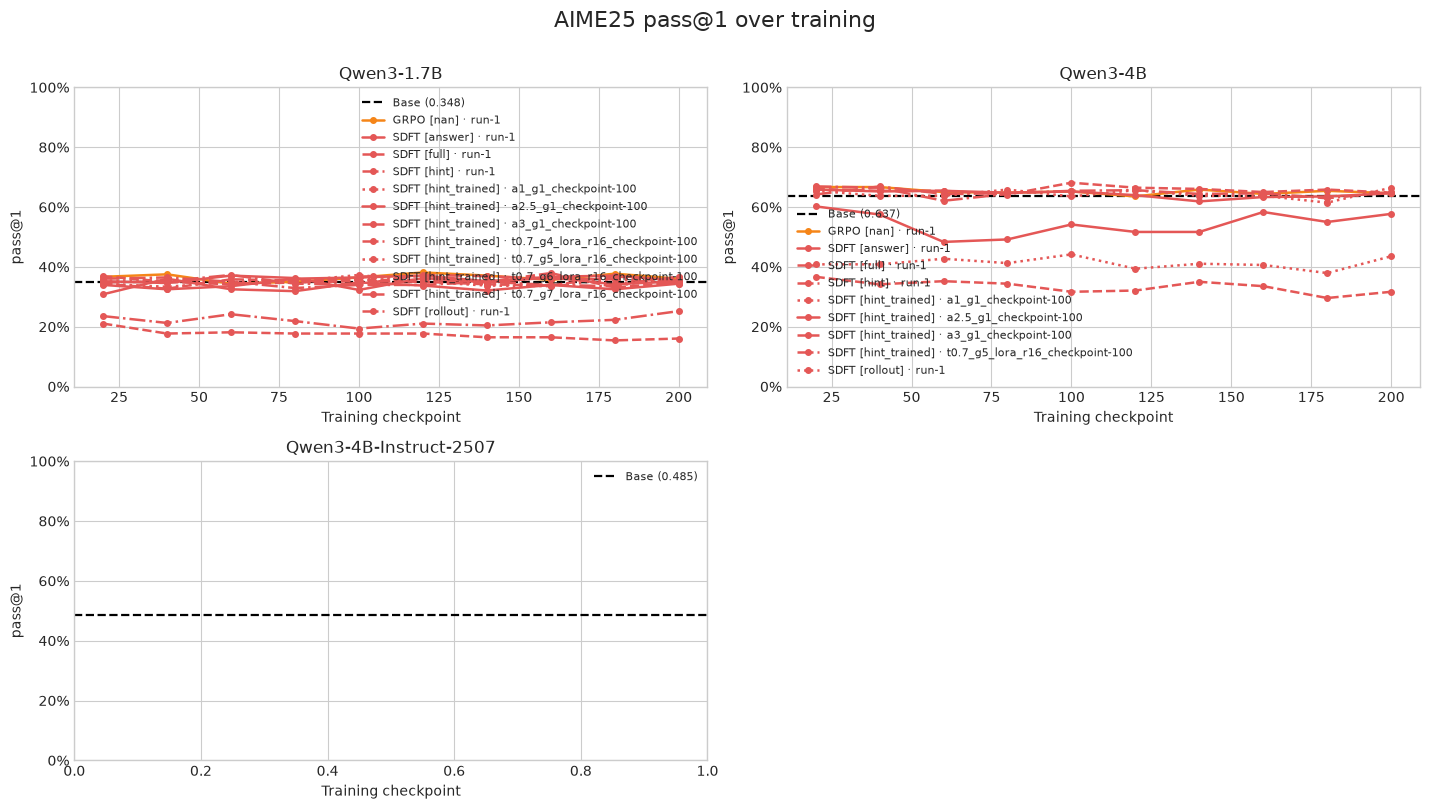

In [13]:
ALGO_COLORS = {
    "sft": "#4c78a8",
    "grpo": "#f58518",
    "gold": "#54a24b",
    "sdft": "#e45756",
    "ppo": "#7a5195",
    "ppo_pi": "#b279a2",
    "ppo_val": "#9c755f",
}
LINESTYLES = ["-", "--", "-.", ":"]


def plot_aime_curves(frame: pd.DataFrame, metric: str = "pass@1", columns: int = 2):
    models = sorted(frame["model"].unique())
    rows = math.ceil(len(models) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(7.2 * columns, 4.0 * rows), squeeze=False)

    for ax, model in zip(axes.flat, models):
        model_frame = frame[frame["model"] == model]
        base = model_frame[model_frame["is_base"]]
        if not base.empty:
            value = base.iloc[-1][metric]
            ax.axhline(value, color="black", linewidth=1.6, linestyle="--", label=f"Base ({value:.3f})")

        trained = model_frame[~model_frame["is_base"]].copy()
        trained["series"] = trained.apply(method_label, axis=1)
        for index, (series, group) in enumerate(trained.groupby("series", sort=True)):
            algo = group.iloc[0]["algo"]
            same_algo_series = sorted(trained.loc[trained["algo"] == algo, "series"].unique())
            style_index = same_algo_series.index(series) % len(LINESTYLES)
            group = group.sort_values("checkpoint")
            ax.plot(
                group["checkpoint"], group[metric], marker="o", markersize=4,
                linewidth=1.8, linestyle=LINESTYLES[style_index],
                color=ALGO_COLORS.get(algo), label=series,
            )

        ax.set_title(model)
        ax.set_xlabel("Training checkpoint")
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8, loc="best")

    for ax in axes.flat[len(models):]:
        ax.set_visible(False)
    fig.suptitle(f"{AIME_LABEL} {metric} over training", fontsize=16, y=1.005)
    fig.tight_layout()
    return fig


plot_aime_curves(aime, "pass@1");

## AIME avg@16 at validation-selected checkpoints

Each row reports the OOD accuracy of the checkpoint selected by the fixed DeepMath
validation set, with one row per algorithm, hyperparameter setting, and training run.
These results are loaded from `results/selected_ood/` and use `AIME_YEAR` above.
They are never selected or ranked by their AIME score. The table shows the chosen
checkpoint, validation accuracy, and AIME avg@16.

Different validation splits or OOD evaluation settings appear in separate tables.
Direct checkpoint evaluations without an embedded validation selection are skipped.


In [4]:
# Selected-checkpoint results use the AIME_YEAR chosen above.
SELECTED_AIME_ROOT = RESULTS / "selected_ood" / AIME_DATASET


def load_selected_aime(directory: Path) -> pd.DataFrame:
    """Read embedded validation selections; never maximize an AIME metric."""
    import hashlib

    rows, unselected = [], []
    for path in sorted(directory.rglob("summary.json")):
        summary = read_json(path)
        config = summary.get("config") or {}
        arm = config.get("arm") or {}
        selection = config.get("selection") or {}
        is_base = arm.get("algo") == "base"
        if not selection and not is_base:
            unselected.append(str(path))
            continue
        if (summary.get("metric") != "avg@16" or summary.get("n_samples") != 16
                or config.get("n") != 16 or config.get("dataset") != directory.name):
            raise ValueError(f"Unexpected avg@16 evaluation metadata: {path}")
        accuracy = float(summary["accuracy"])
        if not math.isfinite(accuracy) or not 0 <= accuracy <= 1:
            raise ValueError(f"Invalid accuracy: {path}")
        if not is_base:
            if config["model"]["model"] != selection["best_checkpoint"]:
                raise ValueError(f"Evaluated model differs from validation selection: {path}")
            if selection.get("metric") != "avg@1" or not selection.get("validation_fingerprint"):
                raise ValueError(f"Missing validation selection provenance: {path}")
        protocol = {
            key: config.get(key)
            for key in ("problems", "max_tokens", "max_model_len", "chat_template_model", "versions")
        }
        protocol["sampling"] = summary.get("sampling")
        protocol["dataset_size"] = summary["dataset_size"]
        protocol_id = hashlib.sha256(json.dumps(protocol, sort_keys=True).encode()).hexdigest()[:12]
        rows.append({
            "model": arm["model"], "algo": arm["algo"],
            "train_dataset": arm.get("train_dataset") or "—",
            "variant": arm.get("variant") or "—",
            "run": arm.get("run") or (Path(selection["run_dir"]).name if selection else "—"),
            "run_dir": selection.get("run_dir", "base"),
            "selected_step": selection.get("best_step"),
            "validation_accuracy": selection.get("best_accuracy"),
            "validation_fingerprint": selection.get("validation_fingerprint", "base"),
            "avg@16": accuracy, "is_base": is_base,
            "max_tokens": config.get("max_tokens"),
            "dataset_size": summary["dataset_size"], "protocol": protocol_id,
            "source": str(path),
        })
    if unselected:
        print(f"Skipped {len(unselected)} direct checkpoint evaluations without a validation selection:")
        print("\n".join(unselected))
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    identity = ["model", "algo", "train_dataset", "variant", "run_dir", "validation_fingerprint", "protocol"]
    duplicate = frame.duplicated(identity, keep=False)
    if duplicate.any():
        raise ValueError(
            "Multiple OOD evaluations for the same run/validation protocol. "
            "Keep the intended selection in this results tree or point SELECTED_AIME_ROOT "
            "at an unambiguous tree; AIME accuracy must not break the tie.\n"
            + "\n".join(frame.loc[duplicate, "source"])
        )
    return frame.sort_values(["model", "algo", "variant", "run"]).reset_index(drop=True)


def display_selected_aime_tables(frame: pd.DataFrame):
    """Show one row per selected training run, grouped by evaluation protocol."""
    trained = frame[~frame["is_base"]]
    if trained.empty:
        print("Only base results are available; no selected training checkpoints yet.")
        return
    groups = trained.groupby(["model", "validation_fingerprint", "protocol"], sort=True)
    for (model, val_id, protocol), table in groups:
        table = table.sort_values(["algo", "train_dataset", "variant", "run"])
        display(
            table[["algo", "variant", "run", "selected_step", "validation_accuracy", "avg@16"]]
            .style.set_caption(
                f"{AIME_LABEL} · {model} · validation-selected checkpoints · "
                f"validation {val_id[:8]} · protocol {protocol[:8]}"
            )
            .format({"selected_step": "{:.0f}", "validation_accuracy": "{:.3f}", "avg@16": "{:.3f}"}, na_rep="—")
            .background_gradient(subset=["avg@16"], cmap="Blues", vmin=0, vmax=1)
        )


selected_aime = load_selected_aime(SELECTED_AIME_ROOT)
if selected_aime.empty:
    print(f"No validation-selected avg@16 results for {AIME_LABEL} yet: {SELECTED_AIME_ROOT}")
else:
    print(f"Loaded {len(selected_aime)} avg@16 summaries from {SELECTED_AIME_ROOT}")
    display_selected_aime_tables(selected_aime)


Loaded 1 avg@16 summaries from /home/ujan/self-distill/results/selected_ood/aime24


,algo,variant,run,selected_step,validation_accuracy,avg@16
0,sdft,hint,deepmath_hint,20,0.836,0.460


## Privileged-information pass@k

These results measure how the same problem-solving model behaves when generation itself is conditioned on no PI, an unverified rollout from the model, a hint, the answer, or the full solution. The raw pass@k values are shown directly; improvements relative to `none` can be added when deeper comparative analysis begins.

Each condition was run at more than one generation-length budget, recorded as `results/passk_pi_<budget>/`. The budgets are discovered from the directory names, so a new budget appears without editing this notebook. Budget matters here: at a short budget a large share of `none` completions are truncated, which depresses its accuracy and inflates every PI contrast.


In [6]:
PI_ORDER = ["none", "rollout", "hint", "answer", "full"]
PI_COLORS = {
    "none": "#9d9d9d",
    "rollout": "#b279a2",
    "hint": "#4c78a8",
    "answer": "#f58518",
    "full": "#54a24b",
}


def budget_sort_key(budget: str) -> int:
    """Order 8k before 16k rather than lexicographically."""
    return int(budget.rstrip("k"))


def discover_budgets() -> list[str]:
    """Read the generation-length budgets off the results directory names."""
    budgets = {
        path.name.split("passk_pi_", 1)[1]
        for path in RESULTS.glob("passk_pi_*")
        if path.is_dir()
    }
    if not budgets:
        raise FileNotFoundError(
            f"No results/passk_pi_<budget>/ directories under {RESULTS}."
        )
    return sorted(budgets, key=budget_sort_key)


BUDGETS = discover_budgets()
BUDGET_ORDER = pd.CategoricalDtype(BUDGETS, ordered=True)
print(f"Budgets found: {BUDGETS}")


def load_passk_pi() -> pd.DataFrame:
    rows = []
    for budget in BUDGETS:
        for path in sorted(RESULTS.glob(f"passk_pi_{budget}/*/passk_pi_summary.json")):
            summary = read_json(path)
            model = summary["model"].split("/")[-1]
            for pi_mode, metrics in summary["pass_at_k"].items():
                rows.append({
                    "budget": budget,
                    "model": model,
                    "model_id": summary["model"],
                    "pi_mode": pi_mode,
                    "n_problems": summary["n_problems"],
                    "n_samples": summary["n_samples"],
                    "max_tokens": summary["max_tokens"],
                    "seed": summary["seed"],
                    "source": str(path.relative_to(ROOT)),
                    **metrics,
                })
    frame = pd.DataFrame(rows)
    if not frame.empty:
        frame["pi_mode"] = pd.Categorical(frame["pi_mode"], PI_ORDER, ordered=True)
        frame["budget"] = frame["budget"].astype(BUDGET_ORDER)
        frame = frame.sort_values(["budget", "model", "pi_mode"]).reset_index(drop=True)
    return frame


passk_pi = load_passk_pi()
print(
    f"Loaded {len(passk_pi)} PI conditions across "
    f"{passk_pi['model'].nunique()} models and {passk_pi['budget'].nunique()} budgets."
)
display(
    passk_pi[[
        "budget", "model", "pi_mode", "pass@1", "pass@8",
        "n_problems", "n_samples", "max_tokens", "seed",
    ]]
    .style.format({"pass@1": "{:.3f}", "pass@8": "{:.3f}"})
    .background_gradient(subset=["pass@1", "pass@8"], cmap="Greens", vmin=0, vmax=1)
)

Budgets found: ['8k', '16k']
Loaded 20 PI conditions across 2 models and 2 budgets.


,budget,model,pi_mode,pass@1,pass@8,n_problems,n_samples,max_tokens,seed
0,8k,Qwen3-1.7B,none,0.645,0.836,128,8,8192,42
1,8k,Qwen3-1.7B,rollout,0.780,0.844,128,8,8192,42
2,8k,Qwen3-1.7B,hint,0.678,0.898,128,8,8192,42
3,8k,Qwen3-1.7B,answer,0.801,0.961,128,8,8192,42
4,8k,Qwen3-1.7B,full,0.998,1.000,128,8,8192,42
5,8k,Qwen3-4B,none,0.682,0.882,127,8,8192,42
6,8k,Qwen3-4B,rollout,0.853,0.906,127,8,8192,42
7,8k,Qwen3-4B,hint,0.726,0.898,127,8,8192,42
8,8k,Qwen3-4B,answer,0.786,0.953,127,8,8192,42
9,8k,Qwen3-4B,full,0.996,1.000,127,8,8192,42


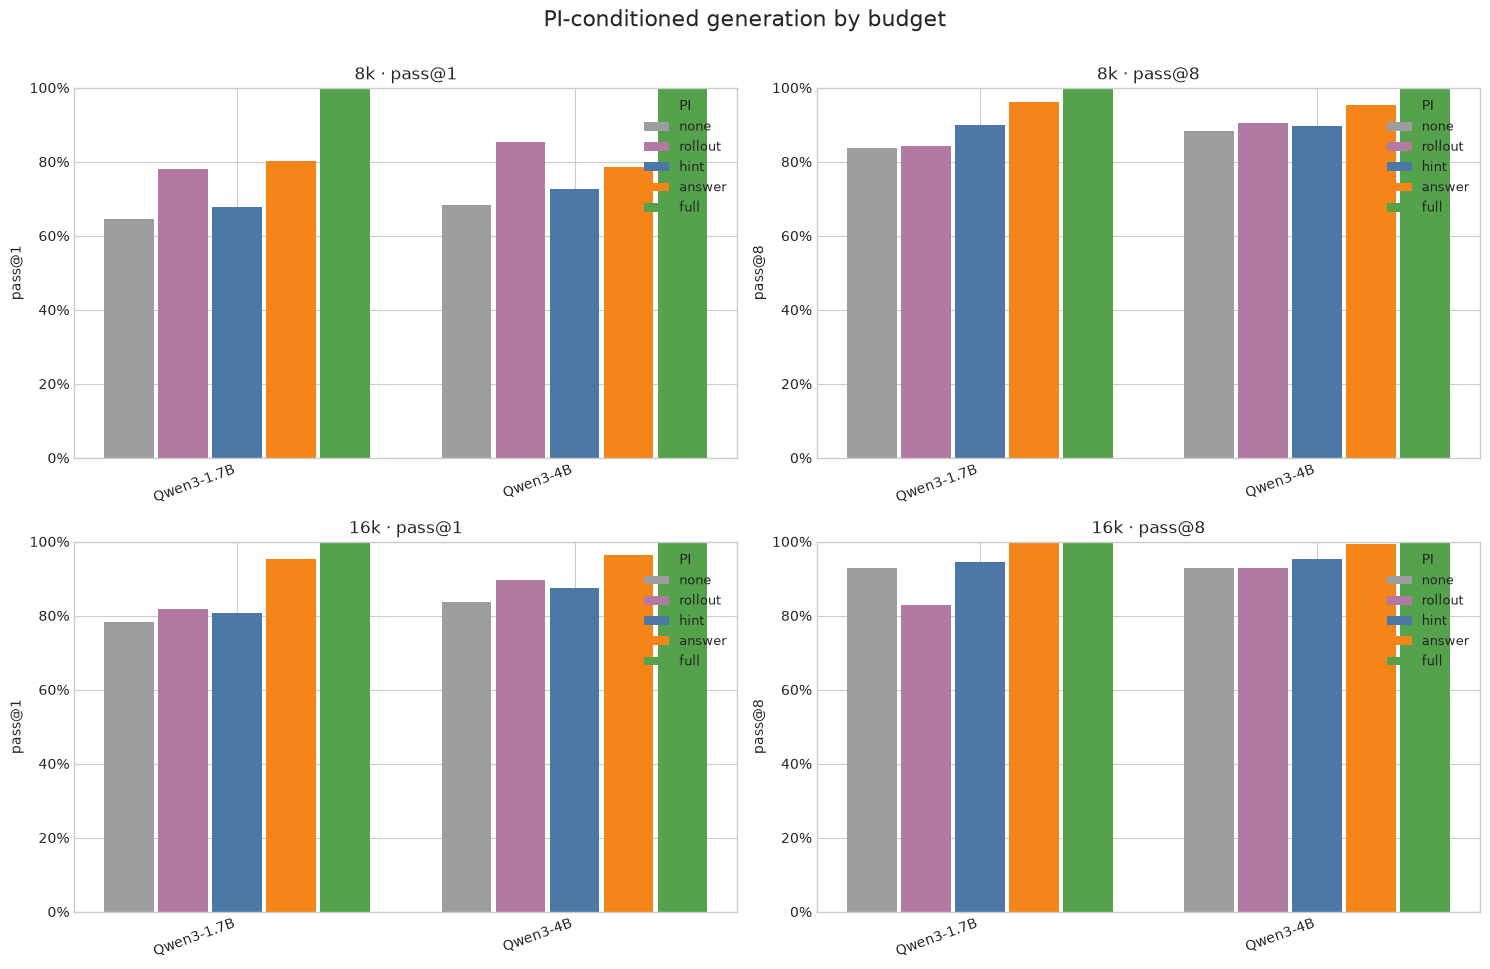

In [7]:
def grouped_bar(ax, frame: pd.DataFrame, value: str, title: str, percent: bool = False):
    models = sorted(frame["model"].unique())
    modes = [mode for mode in PI_ORDER if mode in set(frame["pi_mode"].astype(str))]
    x = np.arange(len(models), dtype=float)
    width = 0.8 / max(len(modes), 1)

    for index, mode in enumerate(modes):
        values = (
            frame[frame["pi_mode"].astype(str) == mode]
            .set_index("model")[value]
            .reindex(models)
        )
        offset = (index - (len(modes) - 1) / 2) * width
        ax.bar(x + offset, values, width=width * 0.92, label=mode, color=PI_COLORS[mode])

    ax.set_xticks(x, models, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(value)
    if percent:
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="PI", fontsize=9)


fig, axes = plt.subplots(
    len(BUDGETS), 2, figsize=(15, 4.8 * len(BUDGETS)), squeeze=False
)
for row, budget in enumerate(BUDGETS):
    panel = passk_pi[passk_pi["budget"] == budget]
    grouped_bar(axes[row, 0], panel, "pass@1", f"{budget} · pass@1", percent=True)
    grouped_bar(axes[row, 1], panel, "pass@8", f"{budget} · pass@8", percent=True)
fig.suptitle("PI-conditioned generation by budget", fontsize=16, y=1.005)
fig.tight_layout()

## Teacher uncertainty

Teacher-uncertainty summaries characterize uncertainty verbalization
while retaining answer accuracy, response length, and truncation as context.
The dashboard keeps differently scaled quantities on separate axes,
making the shift under richer PI visible without combining incompatible units.


In [8]:
def load_teacher_uncertainty() -> tuple[pd.DataFrame, pd.DataFrame]:
    uncertainty_rows = []
    marker_rows = []
    for budget in BUDGETS:
        pattern = f"teacher_uncertainty_{budget}/*/teacher_uncertainty_summary.json"
        for path in sorted(RESULTS.glob(pattern)):
            summary = read_json(path)
            teacher = summary["teacher_model"].split("/")[-1]
            problem_model = summary["problem_model"].split("/")[-1]
            # Newer summaries renamed this block from `uncertainty` to `behavior`.
            conditions = summary.get("uncertainty", summary.get("behavior", {}))
            for pi_mode, metrics in conditions.items():
                common = {
                    "budget": budget,
                    "teacher_model": teacher,
                    "teacher_model_id": summary["teacher_model"],
                    "problem_model": problem_model,
                    "pi_mode": pi_mode,
                    "n_problems": summary["n_problems"],
                    "n_samples": summary["n_samples"],
                    "max_tokens": summary["max_tokens"],
                    "seed": summary["seed"],
                    "source": str(path.relative_to(ROOT)),
                }
                uncertainty_rows.append({
                    **common,
                    **{
                        key: value for key, value in metrics.items()
                        if key != "e_by_marker_per_1k"
                    },
                })
                for marker, value in metrics.get("e_by_marker_per_1k", {}).items():
                    marker_rows.append({**common, "marker": marker, "per_1k_tokens": value})

    uncertainty = pd.DataFrame(uncertainty_rows)
    markers = pd.DataFrame(marker_rows)
    for frame in (uncertainty, markers):
        if not frame.empty:
            frame["pi_mode"] = pd.Categorical(frame["pi_mode"], PI_ORDER, ordered=True)
            frame["budget"] = frame["budget"].astype(BUDGET_ORDER)
            frame.sort_values(["budget", "teacher_model", "pi_mode"], inplace=True)
            frame.reset_index(drop=True, inplace=True)
    return uncertainty, markers


teacher_uncertainty, teacher_markers = load_teacher_uncertainty()
teacher_columns = [
    "budget", "teacher_model", "problem_model", "pi_mode", "pass@1", "mean_tokens",
    "trunc_rate", "unclosed_rate", "mean_e_think", "e_per_1k_tokens", "n_completions",
]
display(
    teacher_uncertainty[teacher_columns]
    .style.format({
        "pass@1": "{:.3f}", "mean_tokens": "{:,.0f}", "trunc_rate": "{:.3f}",
        "unclosed_rate": "{:.3f}", "mean_e_think": "{:.2f}", "e_per_1k_tokens": "{:.2f}",
    })
)

,budget,teacher_model,problem_model,pi_mode,pass@1,mean_tokens,trunc_rate,unclosed_rate,mean_e_think,e_per_1k_tokens,n_completions
0,8k,Qwen3-1.7B,Qwen3-1.7B,none,0.646,"6,164",0.349,0.299,72.07,11.71,1024
1,8k,Qwen3-1.7B,Qwen3-1.7B,rollout,0.781,"2,061",0.073,0.758,10.68,5.21,1024
2,8k,Qwen3-1.7B,Qwen3-1.7B,hint,0.677,"5,782",0.289,0.237,63.11,10.94,1024
3,8k,Qwen3-1.7B,Qwen3-1.7B,answer,0.803,"5,276",0.267,0.231,60.11,11.42,1024
4,8k,Qwen3-1.7B,Qwen3-1.7B,full,0.998,888,0.000,0.983,1.52,1.72,1024
5,8k,Qwen3-4B,Qwen3-4B,none,0.675,"6,207",0.347,0.286,82.70,13.34,1024
6,8k,Qwen3-4B,Qwen3-4B,rollout,0.836,"1,957",0.053,0.658,11.52,5.93,1024
7,8k,Qwen3-4B,Qwen3-4B,hint,0.734,"5,783",0.283,0.221,69.95,12.12,1024
8,8k,Qwen3-4B,Qwen3-4B,answer,0.801,"5,608",0.258,0.212,69.97,12.50,1024
9,8k,Qwen3-4B,Qwen3-4B,full,0.998,"1,285",0.000,0.777,5.11,4.03,1024


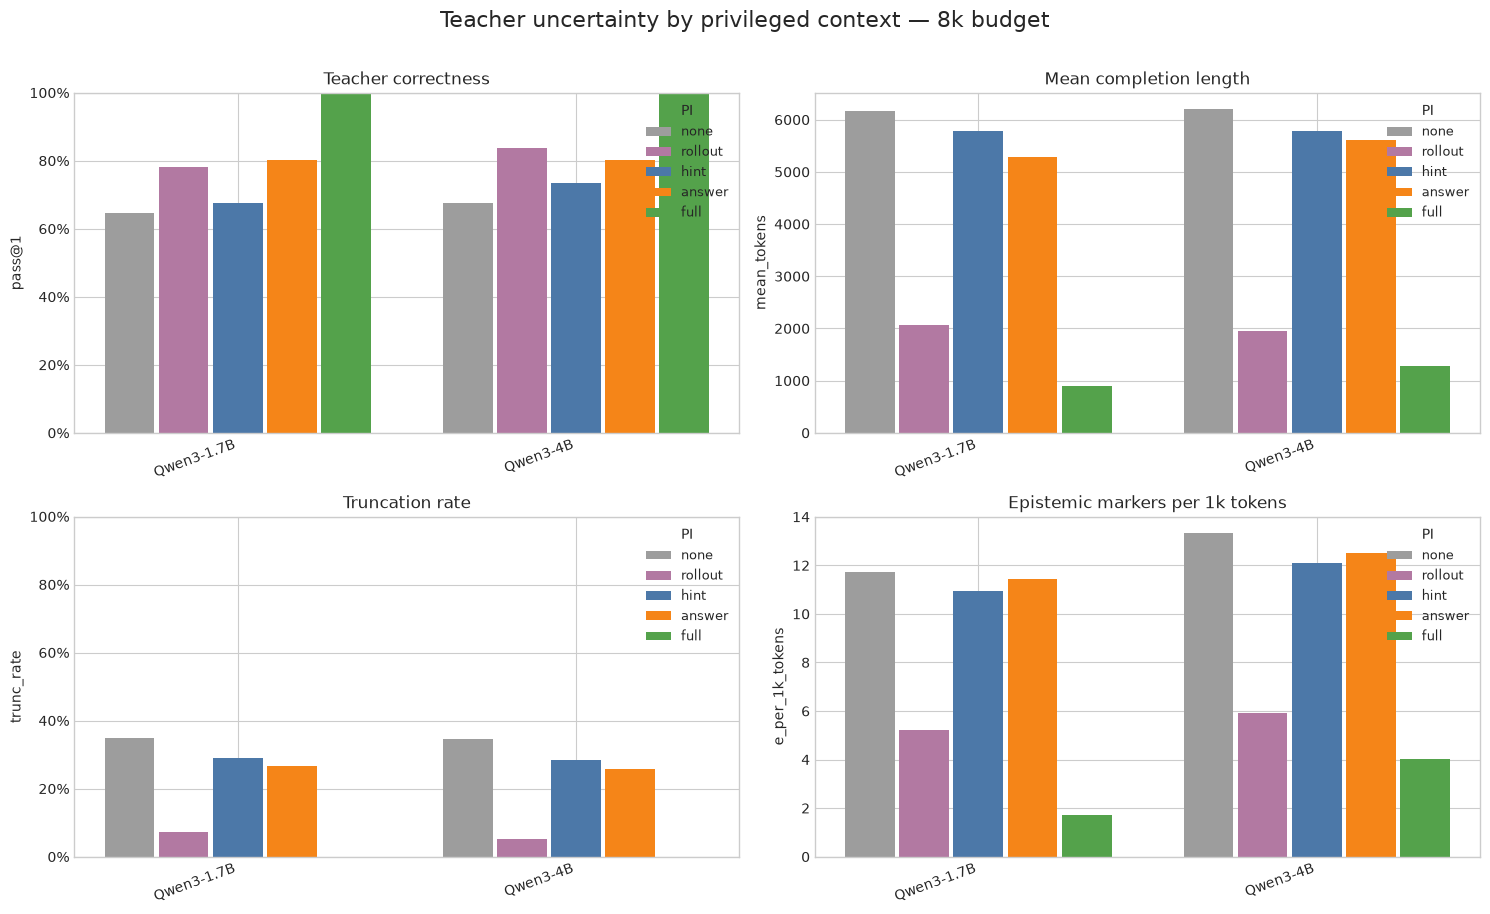

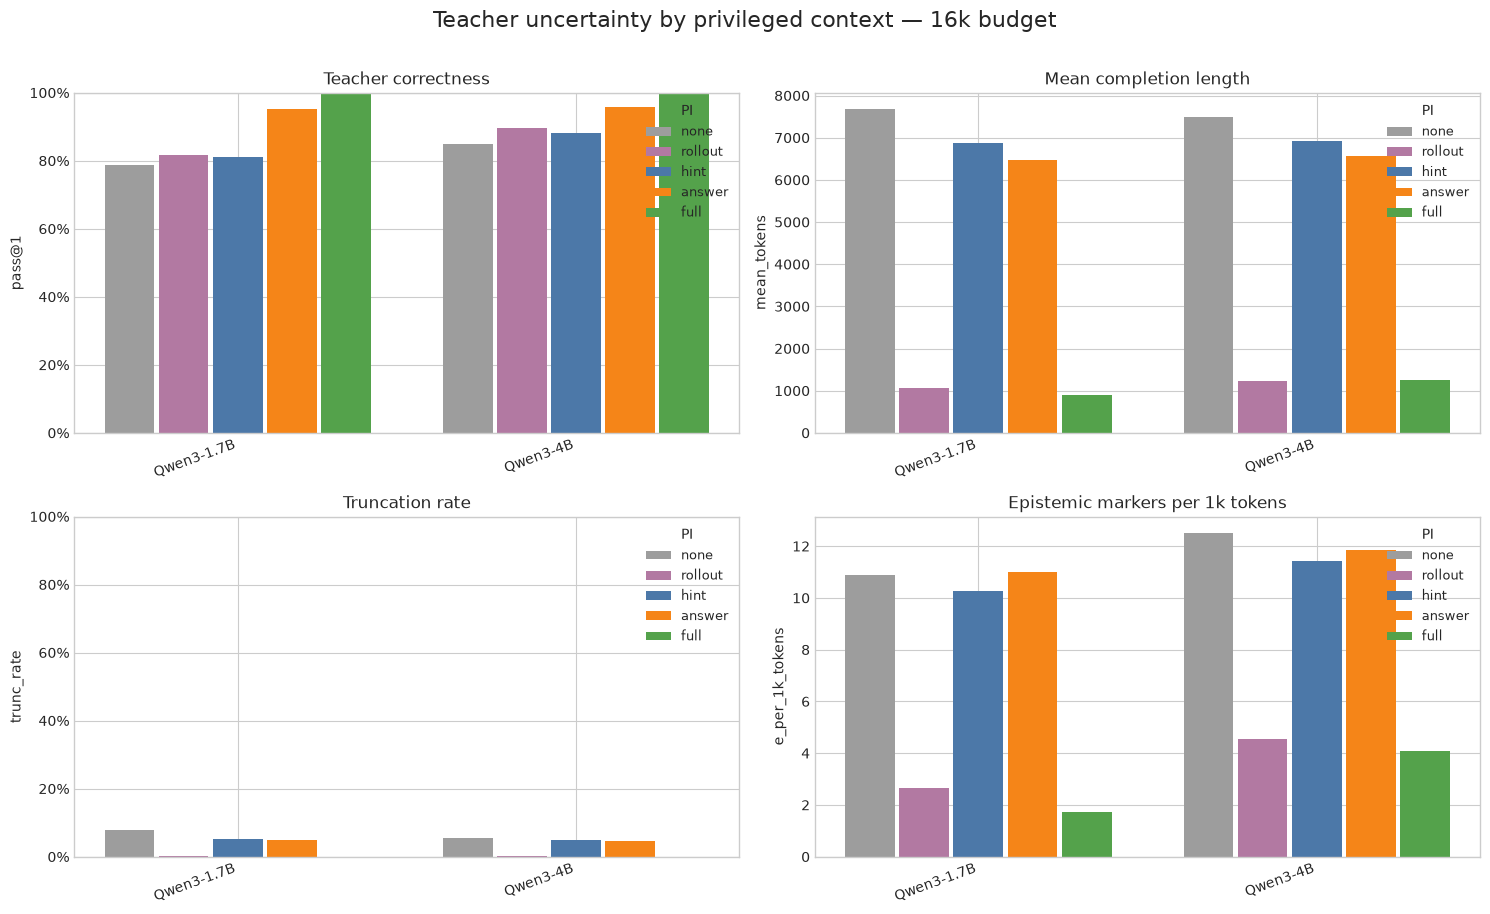

In [9]:
teacher_plot = teacher_uncertainty.rename(columns={"teacher_model": "model"})
for budget in BUDGETS:
    panel = teacher_plot[teacher_plot["budget"] == budget]
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    grouped_bar(axes[0, 0], panel, "pass@1", "Teacher correctness", percent=True)
    grouped_bar(axes[0, 1], panel, "mean_tokens", "Mean completion length")
    grouped_bar(axes[1, 0], panel, "trunc_rate", "Truncation rate", percent=True)
    grouped_bar(axes[1, 1], panel, "e_per_1k_tokens", "Epistemic markers per 1k tokens")
    fig.suptitle(
        f"Teacher uncertainty by privileged context — {budget} budget", fontsize=16, y=1.01
    )
    fig.tight_layout()

## Result inventory and next additions

The inventory below makes missing result families explicit and provides a quick check after adding files. Natural next analysis layers are:

1. paired, per-problem uncertainty estimates from `results.json` rather than treating completions as independent;
2. aggregation across repeated training seeds, with mean and confidence intervals;
3. latest-versus-best checkpoint reporting and checkpoint-selection rules;
4. deltas from each exact base model and learning-curve summaries;
5. response-length, extraction-failure, and per-problem difficulty analysis; and
6. additional benchmark sections using the same tidy-table pattern.


In [10]:
inventory = pd.DataFrame([
    {
        "section": AIME_DATASET,
        "budgets": "—",
        "summary_files": len(aime),
        "models": aime["model"].nunique(),
        "conditions_or_arms": aime[["model", "algo", "variant", "run"]].drop_duplicates().shape[0],
    },
    {
        "section": "passk_pi",
        "budgets": ", ".join(BUDGETS),
        "summary_files": passk_pi["source"].nunique(),
        "models": passk_pi["model"].nunique(),
        "conditions_or_arms": len(passk_pi),
    },
    {
        "section": "teacher_uncertainty",
        "budgets": ", ".join(sorted(
            teacher_uncertainty["budget"].astype(str).unique(), key=budget_sort_key
        )),
        "summary_files": teacher_uncertainty["source"].nunique(),
        "models": teacher_uncertainty["teacher_model"].nunique(),
        "conditions_or_arms": len(teacher_uncertainty),
    },
])
display(inventory)

,section,budgets,summary_files,models,conditions_or_arms
0,aime25,—,163,3,19
1,passk_pi,"8k, 16k",4,2,20
2,teacher_uncertainty,"8k, 16k",4,2,20
